In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import IPython
import dataclasses

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.model import model
from meridian.model import spec

from data_simulator import GeoMediaDataSimulator
from data_simulator import SimulationConfig
from model_utils import build_input_data
from model_utils import filter_param_summary

In [3]:
meridian_root = '/Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic/'

## Overall Setup

In [4]:
config_base = SimulationConfig()  # unchanged defaults, for reference

config = dataclasses.replace(
    config_base,
    current_reach_frac={**config_base.current_reach_frac, 'TV': 0.55},
    seasonal_amplitude={**config_base.seasonal_amplitude, 'TV': 0.9},  # bigger burst/dark swing
    geo_audience_heterogeneity_sd=0.25,  # was 0.12
)

simulator = GeoMediaDataSimulator(config)
config

SimulationConfig(
  n_imp_channels                = 3
  n_controls                    = 3
  n_times                       = 156
  seed_num                      = 1320
  channel_names                 = ['TV', 'Display', 'Social']
  control_names                 = ['sentiment_score', 'competitor_activity_score', 'seasonality_index']
  target_audience_pop_frac      = {'TV': 0.4, 'Display': 0.1, 'Social': 0.15}
  current_reach_frac            = {'TV': 0.55, 'Display': 0.5, 'Social': 0.9}
  frequency_range               = (1.0, 5.0)
  enable_ramp                   = False
  ramp_weeks                    = 10
  time_reach_noise_sd           = 0.03
  frequency_noise_sd            = 0.1
  geo_audience_heterogeneity_sd = 0.25
  demand_seasonal_peak_week     = 47
  seasonal_amplitude            = {'TV': 0.9, 'Display': 0.3, 'Social': 0.1}
  flight_burst_weeks            = {'TV': 8, 'Display': 2, 'Social': 2}
  flight_dark_weeks             = {'TV': 8, 'Display': 2, 'Social': 2}
  flight_floor   

#### 1. Population

Geos are the 50 U.S. states plus the District of Columbia
(`n_geos = 51`), and population $p_g$ for each geo is its actual population
rather than a simulated draw -- U.S. Census Bureau Vintage 2025 population
estimates (see
https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_population).

Using real populations means each channel's target-audience size in a geo
(see the Media Channels section) reflects that state's actual population,
instead of an arbitrary synthetic draw.

In [5]:
p_g = simulator.simulate_population()

#### 2. Controls

Two of the three control variables ($c \in \{\text{sentiment\_score}, \text{competitor\_activity\_score}\}$) are simulated iid, independent of media and the KPI baseline. For each geo $g$, time period $t$,

$$\ddot{z}_{g,t,c} \stackrel{\text{iid}}{\sim} N(0,3) $$

These two are *not* confounders in the causal sense -- they're nuisance covariates Meridian must learn to partial out, but since they don't correlate with media execution they don't create the collinearity that makes real-world MMM hard.

The third control, `seasonality_index`, *is* a genuine confounder: it's the same national demand-seasonality signal used to modulate each channel's execution in Section 3 below (`self.seasonal_index_t`), so it drives both media timing and the KPI baseline through two separate paths -- the "marketers spend more when they expect strong seasonal demand" scenario that makes real-world attribution nontrivial.

In [6]:
transformed_control_gtc = simulator.simulate_controls()

I0000 00:00:1784597825.970152 1888634 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


#### 3. Media Channels

We simulate weekly impressions per channel from a reach x frequency model,
driven by each channel's target-audience share of a geo's own population,
current reach %, and weekly frequency target (see `SimulationConfig`).

For channel $m$, geo $g$, time $t$:

* Target audience: $\text{audience}_{g,m} = \text{TARGET\_AUDIENCE\_POP\_FRAC}_m \cdot p_g \cdot h_{g,m}$, where $h_{g,m}$ is a persistent per-geo, per-channel heterogeneity multiplier representing state-to-state differences in who belongs to a channel's target demographic (age mix, urban/rural mix, media consumption habits, etc.). This replaces allocating a fixed *national* target-audience headcount by population share -- audience size is now a channel-specific percentage of *that geo's own* population, with realistic state-to-state variation in that percentage.
* Reach fraction $r_{t,m}$: centered on $\text{CURRENT\_REACH\_FRAC}_m$, ramped up over the first weeks of the flight, then modulated by three independent, channel-specific execution multipliers layered on top of that flat target (see below), plus AR(1) noise; clipped to $(0.01, 0.95)$. This does not vary by geo -- all geo-level heterogeneity lives in the target-audience size above.
* Frequency $f_{g,t,m}$: drawn near $\text{Uniform}(1, 5)$ per week, with small additional noise.
* Reach count: $\text{reach}_{g,t,m} = r_{t,m} \cdot \text{audience}_{g,m}$.
* Impressions: $x_{g,t,m} = \text{round}(\text{reach}_{g,t,m} \cdot f_{g,t,m})$.

The corresponding Hill half-saturation point (`ec_m`, simulated later) is calibrated so that saturation kicks in once weekly impressions reach roughly the level implied by reaching 50% of the *realized* (heterogeneous) national target audience at this same frequency range.

**Execution multipliers.** Real media execution isn't a flat reach % with white noise -- it has seasonality, on/off campaign flighting, and secular budget trends, and each channel follows its own pattern for its own reasons. $r_{t,m}$ layers three multiplicative components on top of $\text{CURRENT\_REACH\_FRAC}_m$, each independently parameterized per channel in `SimulationConfig`:

* **Seasonality** -- each channel's execution multiplier reacts to the *same* shared national demand-seasonality index (`self.seasonal_index_t`, an annual 52-week cycle anchored to actual calendar week-of-year, peaking at `demand_seasonal_peak_week` -- the Nov/Dec holiday season by default). This is the same signal that populates the `seasonality_index` control (Section 2 above), so it's a genuine confounder rather than a media-only effect. Each channel has its own sensitivity (`seasonal_amplitude`) to that shared signal: TV reacts most strongly (holiday-driven linear-TV buying), Display moderately (promo-calendar buying), Social least (always-on, comparatively flat year-round).
* **Flighting** -- a two-state (on/off) Markov chain per channel with average burst/dark run lengths (`flight_burst_weeks`/`flight_dark_weeks`) and a residual floor multiplier during dark periods (`flight_floor`, never exactly 0 -- there's usually some always-on baseline). TV is bought in short, sharp flights with long dark gaps, matching typical linear-TV campaign buying; Display flights around promo weeks with a moderate floor; Social is modeled as effectively always-on (burst length >= `n_times`) with a high floor, matching always-on programmatic/social buying.
* **Trend** -- a slow secular drift in execution intensity over the full horizon (`trend_pct_total`), e.g. budget shifting away from linear TV toward social over time.

The week-to-week noise on $r_{t,m}$ is also AR(1) rather than iid (`reach_noise_ar1_phi`), since real execution noise persists across adjacent weeks instead of resetting every week.

In [7]:
impression_gtm = simulator.simulate_media()

percentage of sparsity of impression_gtm for each channel: ['0.00%', '0.00%', '0.00%']
TV: mean reach % = 0.380 (nominal target 0.55 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.01 (target range (1.0, 5.0))
Display: mean reach % = 0.400 (nominal target 0.5 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.01 (target range (1.0, 5.0))
Social: mean reach % = 0.753 (nominal target 0.9 -- seasonality /flighting/trend shift the realized average), mean frequency = 3.00 (target range (1.0, 5.0))


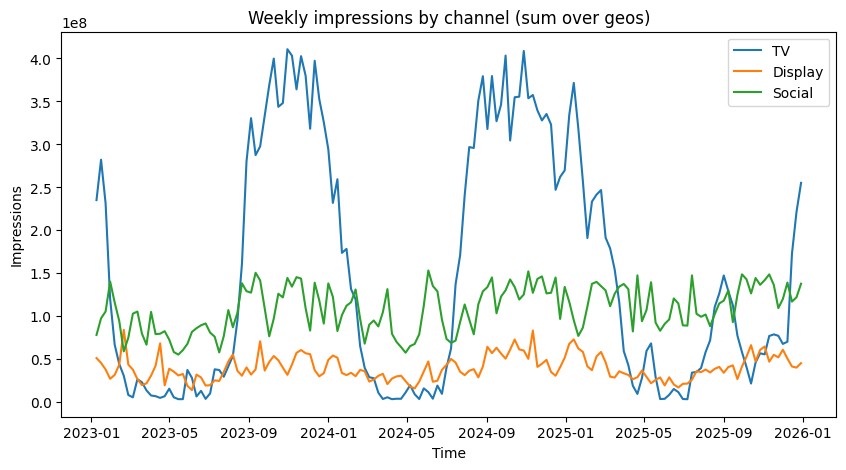

In [8]:
simulator.plot_media_time_series()
plt.show()

#### 5. Cost and Unit-Value

Per-impression cost is derived from a realistic CPM ($ per 1,000 impressions) per channel (`config.cpm_dollars`, default $10 TV / $2 Display / $5 Social, reflecting typical relative linear-TV vs. digital pricing), with a small +/- variability band (`cpm_variability_frac`) for auction/market price fluctuation.

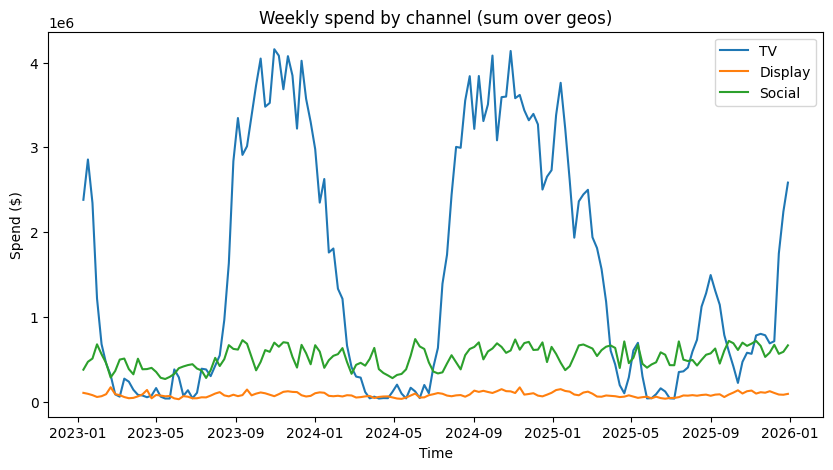

In [9]:
cost_gtm = simulator.simulate_cost_and_unit_value()
simulator.plot_spend_time_series()
plt.show()

#### 4. Time-varying intercepts ($\mu_t$) and geo effects ($\tau_g$)

In [10]:
mu_t = simulator.simulate_intercepts()

#### 6. Coefficients ($\beta_{g,m}$ and $\gamma_{g,c}$) and error term $\epsilon_{g,t}$

For media coefficients,
* $\beta_m \stackrel{iid}{\sim} N(-1.4, 0.1)$
* $\eta_m \stackrel{iid}{\sim} \text{HalfNormal}(0.18)$
* $\beta_{g,m} \big| (\beta_m, \eta_m) \stackrel{iid}{\sim} \text{LogNormal} (\beta_m, \eta_m)$.

`beta_m` is drawn from the *same* hyperprior for every channel, so on its
own it gives each channel an essentially arbitrary relative ROI. Section 8b
below (`calibrate_channel_effects()`) rescales `beta_m`/`beta_gm` per
channel after media/cost are simulated, so the realized ROI matches
`config.target_roi` (default 1.5x TV / 2.0x Display / 3.0x Social --
reflecting TV's high CPM/broad-reach inefficiency vs. digital channels'
lower CPM and tighter targeting).

For control coefficients,
* $\gamma_c \stackrel{iid}{\sim} N(3.5, 0.5)$
* $\xi_c \stackrel{iid}{\sim} \text{HalfNormal}(0.3)$
* $\gamma_{g,c} \big| (\gamma_c, \xi_c) \stackrel{iid}{\sim} N(\gamma_c, \xi_c)$.

For residual variance,
* $\epsilon_{g,t} \stackrel{iid}{\sim} N(0, 0.5)$.

In [11]:
beta_gm = simulator.simulate_coefficients()

#### 7. Simulate Adstock / Hill Params

In [12]:
ec_m = simulator.simulate_adstock_hill_params()
print(f"simulated alpha_m: {simulator.alpha_m.numpy()}")
print(f"simulated ec_m: {simulator.ec_m.numpy()}")
print(f"simulated slope_m: {simulator.slope_m.numpy()}")


ec_m = [2.484409   1.4412162  0.71143585]
simulated alpha_m: [0.74826247 0.2828253  0.23166814]
simulated ec_m: [2.484409   1.4412162  0.71143585]
simulated slope_m: [1. 1. 1.]


#### 8. Transform the Media

In [13]:
media_transformed = simulator.transform_media()

#### 8b. Calibrate Channel Effects to Target ROI

Rescales `beta_m`/`beta_gm` per channel so realized ROI matches `config.target_roi`, since `beta_m` alone (Section 6) gives each channel an arbitrary relative ROI.

In [14]:
beta_gm = simulator.calibrate_channel_effects()

#### 9. Generate KPI and Revenue

In [15]:
kpi_gt = simulator.generate_kpi_and_revenue()

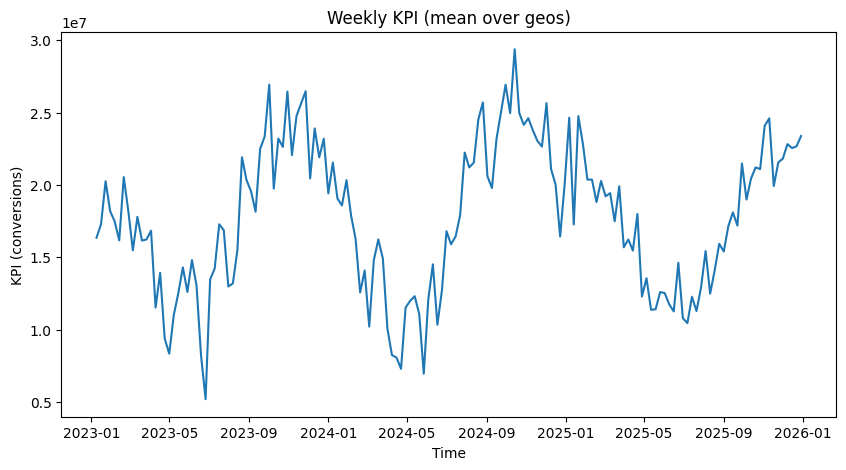

In [16]:
simulator.plot_kpi_time_series()
plt.show()

#### 10. Combine into a DataFrame

In [17]:
geo_data_df = simulator.to_dataframe()
geo_data_df.head()

,geo,time,Display_impression,Social_impression,TV_impression,competitor_activity_score_control,seasonality_index_control,sentiment_score_control,Display_spend,Social_spend,TV_spend,Display_reach,Social_reach,TV_reach,Display_frequency,Social_frequency,TV_frequency,conversions,revenue_per_conversion,population
0,Alabama,2023-01-09,1151090.0,2020824.0,2762686.0,0.537944,0.737785,1.351428,2316.168457,9725.174805,27956.746094,234875.281250,475505.8125,871642.25000,4.900856,4.249840,3.169518,15626925.0,0.035049,5193088.0
1,Alabama,2023-01-16,383747.0,1420115.0,4699848.0,0.845643,0.593424,0.657998,772.157410,6834.274902,47559.675781,237291.937500,451853.2500,945194.87500,1.617194,3.142868,4.972359,18149924.0,0.034529,5193088.0
2,Alabama,2023-01-23,182103.0,2404846.0,2552594.0,-0.233666,0.440453,0.900505,366.419006,11573.273438,25830.740234,166279.640625,531139.7500,746694.62500,1.095160,4.527709,3.418525,17870658.0,0.034954,5193088.0
3,Alabama,2023-01-30,194692.0,1339965.0,2039968.0,-0.754862,0.281102,-2.214974,391.749969,6448.554688,20643.267578,121585.039062,609791.4375,496360.00000,1.601279,2.197415,4.109857,8092885.0,0.034622,5193088.0
4,Alabama,2023-02-06,461549.0,2498832.0,523989.0,-0.093950,0.117695,-1.280288,928.706909,12025.579102,5302.458496,152782.031250,530369.1875,286558.96875,3.020961,4.711496,1.828554,10731760.0,0.034928,5193088.0


In [18]:
geo_data_df.to_csv('./real_world_simulated_geo_data.csv')

#### 11. Ground Truth

Obtain ground-truths to ensure comparison with posterior samples at the same scale.

In [19]:
ground_truth = simulator.compute_ground_truth()

ground-truth ROI for every channel = [2.4999988 1.4999996 2.       ]
ground-truth total incremental ROI = 2.34

Total revenue = 140852.36M
Total ROI = 428.29705810546875


Model Build

Note: `n_geos = 51` here (vs. 10 in the original notebook), so
`sample_posterior` below will take noticeably longer to run -- consider
lowering `n_adapt`/`n_burnin`/`n_keep` for a quick smoke test before doing a
full run.

In [20]:
data = build_input_data(
    geo_data_df, config.channel_names, simulator.control_col_names
)

In [21]:
model_spec = spec.ModelSpec(
    media_prior_type='roi', media_effects_dist='log_normal', knots=8
)


In [22]:
mmm = model.Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(500)
mmm.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

2026-07-20 20:38:09.217390: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [23]:
# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [24]:
model_diagnostics_df

,metric,geo_granularity,value
0,R_Squared,geo,0.983078
1,R_Squared,national,0.869195
2,MAPE,geo,0.126996
3,MAPE,national,0.096845
4,wMAPE,geo,0.086068
5,wMAPE,national,0.082212


In [25]:
filter_param_summary(model_summary_df, 'ec_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],0.720,0.077,0.580,0.867,0.002,0.001,1450.0,1401.0,1.0,0.720
160,ec_m[Display],1.075,0.612,0.102,2.117,0.013,0.009,1685.0,767.0,1.0,1.014
161,ec_m[Social],0.112,0.014,0.100,0.137,0.000,0.000,762.0,868.0,1.0,0.108


In [26]:
filter_param_summary(model_summary_df, 'alpha_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.990,0.009,0.973,1.0,0.000,0.000,1377.0,982.0,1.0,0.992
1,alpha_m[Display],0.717,0.250,0.197,1.0,0.007,0.005,1242.0,1036.0,1.0,0.798
2,alpha_m[Social],0.982,0.016,0.953,1.0,0.000,0.000,1419.0,853.0,1.0,0.986


In [27]:
filter_param_summary(model_summary_df, 'roi_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],3.630,0.159,3.316,3.906,0.004,0.003,1768.0,1321.0,1.0,3.629
486,roi_m[Display],1.602,1.805,0.066,4.708,0.057,0.040,1234.0,1455.0,1.0,1.006
487,roi_m[Social],15.977,2.426,11.382,20.290,0.131,0.092,346.0,614.0,1.0,15.996


In [28]:
from meridian.analysis.review import reviewer

health_summary = reviewer.ModelReviewer(mmm).run()

filename = 'health_card.html'
health_summary.output_model_health_card(filename=filename, filepath=meridian_root)
IPython.display.HTML(filename=f'{meridian_root}{filename}')

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_77299/3489592603.py:3: DeprecationWarning: The `meridian` argument is deprecated. Please use `model_context` and `inference_data` instead.
  health_summary = reviewer.ModelReviewer(mmm).run()


Metric check,Status,Recommended action
Convergence,Pass,"The model has likely converged, as all parameters have R-hat values < 1.2."
Baseline,Pass,The posterior probability that the baseline is negative is 0.00. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
Bayesian p-value,Pass,The Bayesian posterior predictive p-value is 0.97. The observed total outcome is consistent with the model's posterior predictive distribution.
Goodness of fit,Pass,"R-squared = 0.9831, MAPE = 0.1270, and wMAPE = 0.0861. These goodness-of-fit metrics are intended for guidance and relative comparison."
Prior-posterior shift,Pass 3/3 channels passed,The model has successfully learned from the data. This is a positive sign that your data was informative.


In [29]:
meffects_period_full = visualizer.MediaSummary(mmm).summary_table()
meffects_period_full

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$454,157,120 ($70,775,928, $1,455,626,752)","7.6% (1.2%, 24.5%)","1.9 (0.3, 6.2)","0.02 (0.00, 0.06)","0.7 (0.1, 1.9)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$851,672,448 ($789,745,600, $913,234,432)","17.3% (16.0%, 18.5%)","3.6 (3.4, 3.9)","0.04 (0.03, 0.04)","1.1 (1.1, 1.2)","$0.0 ($0.0, $0.0)"
2,Display,prior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$24,374,074 ($3,290,168, $64,950,908)","0.4% (0.1%, 1.1%)","1.9 (0.3, 5.2)","0.00 (0.00, 0.01)","0.8 (0.1, 2.5)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$20,190,248 ($3,000,980, $65,252,364)","0.4% (0.1%, 1.3%)","1.6 (0.2, 5.2)","0.00 (0.00, 0.01)","0.7 (0.1, 2.5)","$0.0 ($0.0, $0.1)"
4,Social,prior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$150,768,464 ($21,009,950, $451,651,936)","2.5% (0.4%, 7.6%)","1.8 (0.3, 5.5)","0.01 (0.00, 0.03)","0.8 (0.1, 2.7)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$1,304,722,048 ($975,082,880, $1,614,475,648)","26.5% (19.8%, 32.7%)","16.0 (11.9, 19.8)","0.08 (0.06, 0.10)","1.7 (1.3, 2.0)","$0.0 ($0.0, $0.0)"
6,All Channels,prior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$629,299,776 ($162,276,832, $1,613,243,520)","10.6% (2.7%, 27.1%)","1.9 (0.5, 4.9)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$2,176,588,544 ($1,865,198,208, $2,471,791,360)","44.1% (37.8%, 50.1%)","6.6 (5.7, 7.5)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


In [30]:
simulator.ground_truth['roi_m']

array([2.4999988, 1.4999996, 2.       ], dtype=float32)

Informed Priors

In [31]:
# -- half saturation prior
import tensorflow_probability as tfp
from meridian import constants
from meridian.model import prior_distribution

half_saturation_multiplier_prior = {
    'TV': [2.5, 0.1],
    'Display': [1.5, 0.1],
    'Social': [0.7, 0.1]
}

ordered_chnl_names = config.channel_names  # ['TV', 'Display', 'Social']
ec50_mu_array = [half_saturation_multiplier_prior[col][0] for col in ordered_chnl_names]
ec50_deviation_pct_array = [half_saturation_multiplier_prior[col][1] for col in ordered_chnl_names]
ec50_log_loc_array = np.log(ec50_mu_array)
ec50_scale_array = np.array(ec50_deviation_pct_array)  # kept as-is, not scaled by mu

ec_m = tfp.distributions.LogNormal(
    loc=[float(x) for x in ec50_log_loc_array],
    scale=[float(x) for x in ec50_scale_array],
    name=constants.EC_M)


prior = prior_distribution.PriorDistribution(ec_m=ec_m)
model_spec2 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)


In [32]:
mmm2 = model.Meridian(input_data=data, model_spec=model_spec2)
mmm2.sample_prior(500)
mmm2.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

2026-07-20 20:43:38.955136: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [33]:
# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm2)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm2.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

model_diagnostics_df

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,metric,geo_granularity,value
0,R_Squared,geo,0.982889
1,R_Squared,national,0.867051
2,MAPE,geo,0.127665
3,MAPE,national,0.097701
4,wMAPE,geo,0.086540
5,wMAPE,national,0.083158


In [34]:
filter_param_summary(model_summary_df, 'ec_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],1.342,0.098,1.159,1.525,0.002,0.001,2579.0,1467.0,1.0,1.339
160,ec_m[Display],1.512,0.152,1.236,1.792,0.002,0.002,3989.0,1191.0,1.0,1.503
161,ec_m[Social],0.653,0.068,0.541,0.792,0.002,0.001,1637.0,1532.0,1.0,0.649


In [35]:
filter_param_summary(model_summary_df, 'alpha_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.977,0.015,0.950,1.0,0.000,0.000,1015.0,950.0,1.0,0.979
1,alpha_m[Display],0.820,0.192,0.429,1.0,0.005,0.004,1306.0,1005.0,1.0,0.886
2,alpha_m[Social],0.933,0.108,0.849,1.0,0.008,0.005,590.0,344.0,1.0,0.958


In [36]:
filter_param_summary(model_summary_df, 'roi_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],3.287,0.137,3.032,3.547,0.003,0.002,1651.0,1088.0,1.0,3.289
486,roi_m[Display],4.190,4.626,0.083,14.200,0.247,0.181,584.0,469.0,1.0,2.255
487,roi_m[Social],4.033,1.344,1.291,6.293,0.068,0.048,404.0,234.0,1.0,4.071


In [37]:
meffects_period_full = visualizer.MediaSummary(mmm2).summary_table()
meffects_period_full

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$428,417,472 ($63,792,264, $1,255,938,304)","7.8% (1.2%, 22.8%)","1.8 (0.3, 5.4)","0.02 (0.00, 0.05)","0.9 (0.1, 2.7)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$771,221,760 ($717,708,544, $823,166,784)","15.6% (14.6%, 16.7%)","3.3 (3.1, 3.5)","0.03 (0.03, 0.04)","1.3 (1.2, 1.4)","$0.0 ($0.0, $0.0)"
2,Display,prior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$22,466,562 ($3,993,842, $67,178,792)","0.4% (0.1%, 1.2%)","1.8 (0.3, 5.3)","0.00 (0.00, 0.01)","1.0 (0.2, 3.0)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$52,813,780 ($4,196,481, $189,410,832)","1.1% (0.1%, 3.8%)","4.2 (0.3, 15.0)","0.01 (0.00, 0.03)","2.4 (0.2, 8.5)","$0.0 ($0.0, $0.1)"
4,Social,prior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$134,649,488 ($23,578,942, $363,376,480)","2.4% (0.4%, 6.6%)","1.6 (0.3, 4.4)","0.01 (0.00, 0.02)","0.7 (0.1, 1.7)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$329,342,400 ($135,566,416, $496,447,424)","6.7% (2.7%, 10.1%)","4.0 (1.7, 6.1)","0.02 (0.01, 0.03)","1.5 (0.7, 2.3)","$0.0 ($0.0, $0.0)"
6,All Channels,prior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$585,533,568 ($155,178,048, $1,418,472,960)","10.6% (2.8%, 25.7%)","1.8 (0.5, 4.3)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$1,153,379,584 ($997,266,240, $1,299,906,688)","23.4% (20.2%, 26.4%)","3.5 (3.0, 4.0)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


Informed Prior ==> Half Saturation and Adstock

In [38]:
# -- adstock prior
adstock_prior = {
    'TV': [0.6, 0.8],
    'Display': [0, 0.4],
    'Social': [0.1, 0.4]
}

adstock_lower_bounds = [adstock_prior[col][0] for col in ordered_chnl_names]
adstock_upper_bounds = [adstock_prior[col][1] for col in ordered_chnl_names]
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)


prior = prior_distribution.PriorDistribution(ec_m=ec_m, alpha_m=alpha_m)
model_spec3 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)
mmm3 = model.Meridian(input_data=data, model_spec=model_spec3)
mmm3.sample_prior(500)
mmm3.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

2026-07-20 20:48:42.374267: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [39]:
# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm3)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm3.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

model_diagnostics_df

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,metric,geo_granularity,value
0,R_Squared,geo,0.982468
1,R_Squared,national,0.862478
2,MAPE,geo,0.129279
3,MAPE,national,0.099010
4,wMAPE,geo,0.087745
5,wMAPE,national,0.084499


In [40]:
filter_param_summary(model_summary_df, 'ec_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],1.670,0.116,1.455,1.889,0.003,0.002,1648.0,1357.0,1.00,1.663
160,ec_m[Display],1.487,0.147,1.234,1.764,0.006,0.005,569.0,1185.0,1.00,1.478
161,ec_m[Social],0.705,0.071,0.575,0.834,0.005,0.003,214.0,554.0,1.01,0.703


In [41]:
filter_param_summary(model_summary_df, 'alpha_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.799,0.001,0.797,0.800,0.000,0.000,371.0,583.0,1.01,0.799
1,alpha_m[Display],0.245,0.114,0.042,0.400,0.004,0.004,698.0,1052.0,1.01,0.262
2,alpha_m[Social],0.260,0.093,0.117,0.399,0.005,0.003,436.0,679.0,1.01,0.262


In [42]:
filter_param_summary(model_summary_df, 'roi_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],3.354,0.129,3.101,3.566,0.009,0.006,212.0,208.0,1.01,3.358
486,roi_m[Display],0.809,0.633,0.083,2.045,0.070,0.050,98.0,39.0,1.03,0.632
487,roi_m[Social],1.331,0.518,0.335,2.216,0.025,0.018,413.0,689.0,1.01,1.305


In [43]:
meffects_period_full = visualizer.MediaSummary(mmm3).summary_table()
meffects_period_full

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$384,887,680 ($63,994,588, $1,100,375,808)","7.1% (1.2%, 20.3%)","1.6 (0.3, 4.7)","0.02 (0.00, 0.05)","0.8 (0.1, 2.4)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$786,873,216 ($734,068,288, $833,528,832)","16.0% (14.9%, 16.9%)","3.4 (3.1, 3.6)","0.03 (0.03, 0.04)","1.5 (1.4, 1.6)","$0.0 ($0.0, $0.0)"
2,Display,prior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$23,783,248 ($3,801,183, $65,159,776)","0.4% (0.1%, 1.2%)","1.9 (0.3, 5.2)","0.00 (0.00, 0.01)","1.1 (0.2, 2.9)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$10,198,233 ($1,571,331, $27,329,984)","0.2% (0.0%, 0.6%)","0.8 (0.1, 2.2)","0.00 (0.00, 0.00)","0.4 (0.1, 1.2)","$0.1 ($0.0, $0.3)"
4,Social,prior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$154,089,152 ($24,045,980, $435,557,184)","2.8% (0.4%, 8.1%)","1.9 (0.3, 5.3)","0.01 (0.00, 0.03)","0.8 (0.1, 2.1)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$108,677,200 ($43,580,996, $181,031,264)","2.2% (0.9%, 3.7%)","1.3 (0.5, 2.2)","0.01 (0.00, 0.01)","0.5 (0.2, 0.9)","$0.0 ($0.0, $0.1)"
6,All Channels,prior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$562,759,872 ($154,329,328, $1,426,403,968)","10.4% (2.9%, 26.4%)","1.7 (0.5, 4.3)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$905,749,440 ($827,582,720, $988,678,464)","18.4% (16.8%, 20.0%)","2.8 (2.5, 3.0)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


Informed Priors - Adstock ONLY

In [44]:
# -- adstock prior
adstock_prior = {
    'TV': [0.6, 0.8],
    'Display': [0, 0.4],
    'Social': [0.1, 0.4]
}

adstock_lower_bounds = [adstock_prior[col][0] for col in ordered_chnl_names]
adstock_upper_bounds = [adstock_prior[col][1] for col in ordered_chnl_names]
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)

prior = prior_distribution.PriorDistribution(alpha_m=alpha_m)
model_spec4 = spec.ModelSpec(prior=prior, media_prior_type='roi', media_effects_dist='log_normal', knots=8)
mmm4 = model.Meridian(input_data=data, model_spec=model_spec4)
mmm4.sample_prior(500)
mmm4.sample_posterior(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

2026-07-20 20:52:51.203476: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [45]:
# 1. model diagnostics
model_diagnostics = visualizer.ModelDiagnostics(mmm3)
model_diagnostics_df = model_diagnostics.predictive_accuracy_table().copy()

# 2. model parameters summary
model_summary_df = az.summary(
    mmm3.inference_data,
    stat_funcs={'median': lambda x: np.median(x, axis=0)},
    extend=True,
).reset_index()

model_diagnostics_df

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,metric,geo_granularity,value
0,R_Squared,geo,0.982468
1,R_Squared,national,0.862478
2,MAPE,geo,0.129279
3,MAPE,national,0.099010
4,wMAPE,geo,0.087745
5,wMAPE,national,0.084499


In [46]:
filter_param_summary(model_summary_df, 'ec_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
159,ec_m[TV],1.670,0.116,1.455,1.889,0.003,0.002,1648.0,1357.0,1.00,1.663
160,ec_m[Display],1.487,0.147,1.234,1.764,0.006,0.005,569.0,1185.0,1.00,1.478
161,ec_m[Social],0.705,0.071,0.575,0.834,0.005,0.003,214.0,554.0,1.01,0.703


In [47]:
filter_param_summary(model_summary_df, 'alpha_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
0,alpha_m[TV],0.799,0.001,0.797,0.800,0.000,0.000,371.0,583.0,1.01,0.799
1,alpha_m[Display],0.245,0.114,0.042,0.400,0.004,0.004,698.0,1052.0,1.01,0.262
2,alpha_m[Social],0.260,0.093,0.117,0.399,0.005,0.003,436.0,679.0,1.01,0.262


In [48]:
filter_param_summary(model_summary_df, 'roi_m')

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
485,roi_m[TV],3.354,0.129,3.101,3.566,0.009,0.006,212.0,208.0,1.01,3.358
486,roi_m[Display],0.809,0.633,0.083,2.045,0.070,0.050,98.0,39.0,1.03,0.632
487,roi_m[Social],1.331,0.518,0.335,2.216,0.025,0.018,413.0,689.0,1.01,1.305


In [49]:
meffects_period_full = visualizer.MediaSummary(mmm4).summary_table()
meffects_period_full

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$421,796,032 ($59,993,040, $1,255,405,440)","7.5% (1.1%, 22.3%)","1.8 (0.3, 5.4)","0.02 (0.00, 0.05)","0.6 (0.1, 1.9)","$0.0 ($0.0, $0.1)"
1,TV,posterior,"23,183,192,064",50%,"$234,600,608",71%,$10,"$855,071,232 ($799,921,152, $910,488,064)","17.3% (16.2%, 18.5%)","3.6 (3.4, 3.9)","0.04 (0.03, 0.04)","1.4 (1.3, 1.4)","$0.0 ($0.0, $0.0)"
2,Display,prior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$22,436,504 ($3,432,912, $65,023,552)","0.4% (0.1%, 1.2%)","1.8 (0.3, 5.2)","0.00 (0.00, 0.01)","0.8 (0.1, 2.2)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"6,264,695,808",13%,"$12,605,513",4%,$2,"$9,930,229 ($2,525,337, $23,046,334)","0.2% (0.1%, 0.5%)","0.8 (0.2, 1.8)","0.00 (0.00, 0.00)","0.3 (0.1, 0.8)","$0.1 ($0.0, $0.2)"
4,Social,prior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$148,482,560 ($24,970,556, $419,227,904)","2.6% (0.4%, 7.4%)","1.8 (0.3, 5.1)","0.01 (0.00, 0.02)","0.8 (0.1, 2.4)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"16,968,403,968",37%,"$81,660,144",25%,$5,"$88,789,480 ($36,427,072, $152,429,632)","1.8% (0.7%, 3.1%)","1.1 (0.4, 1.9)","0.01 (0.00, 0.01)","0.6 (0.2, 0.9)","$0.0 ($0.0, $0.1)"
6,All Channels,prior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$592,715,136 ($163,085,360, $1,409,442,176)","10.5% (2.9%, 25.0%)","1.8 (0.5, 4.3)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"46,416,293,888",100%,"$328,866,272",100%,$7,"$953,790,784 ($880,002,624, $1,035,176,704)","19.3% (17.8%, 21.0%)","2.9 (2.7, 3.1)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"
